In [3]:
import pandas as pd

In [5]:
df = pd.read_csv(r"synthetic_crime_data.csv")
df

,Crime_ID,Date,City,Crime_Type,Severity,Victim_Age,Suspect_Age,Weapon_Used,Latitude,Longitude,Arrested,Reported_By,Police_Response_Time,Evidence_Found,Case_Status
0,1,2024-04-23,Bengaluru,Theft,1,22.0,62.0,Knife,13.245867,77.864072,False,Citizen,43.0,False,Closed
1,2,2024-03-01,Delhi,Assault,7,15.0,80.0,Poison,13.294993,77.653383,False,Journalist,50.0,False,Pending Investigation
2,3,2024-02-13,Chennai,Theft,2,39.0,21.0,Poison,13.488667,78.229783,False,Anonymous,45.0,False,Pending Investigation
3,4,2024-01-26,Mumbai,Theft,4,75.0,50.0,NaN,12.741379,78.040523,True,Anonymous,47.0,False,Open
4,5,2024-04-08,Hyderabad,Robbery,3,44.0,73.0,Knife,13.008358,77.527951,True,Citizen,44.0,True,Closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,860,2024-04-05,Hyderabad,Robbery,8,27.0,77.0,Knife,13.104464,77.844762,False,Citizen,5.0,False,Pending Investigation
1046,634,2024-04-27,Delhi,Assault,9,21.0,79.0,Gun,12.529543,78.496788,False,Journalist,45.0,True,Open
1047,802,2024-03-19,Pune,Assault,5,64.0,54.0,Gun,12.910534,77.740095,False,Citizen,23.0,True,Closed
1048,661,2024-03-03,Mumbai,Fraud,7,37.0,67.0,Blunt Object,12.889512,78.475722,True,Citizen,NaN,True,Open


In [203]:
#EDA on the dataset
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Crime_ID              1050 non-null   int64  
 1   Date                  1050 non-null   object 
 2   City                  1050 non-null   object 
 3   Crime_Type            1050 non-null   object 
 4   Severity              1050 non-null   int64  
 5   Victim_Age            985 non-null    float64
 6   Suspect_Age           951 non-null    float64
 7   Weapon_Used           877 non-null    object 
 8   Latitude              1050 non-null   float64
 9   Longitude             1050 non-null   float64
 10  Arrested              1050 non-null   bool   
 11  Reported_By           1050 non-null   object 
 12  Police_Response_Time  957 non-null    float64
 13  Evidence_Found        1050 non-null   bool   
 14  Case_Status           1050 non-null   object 
dtypes: bool(2), float64(5

In [205]:
df.dtypes

Crime_ID                  int64
Date                     object
City                     object
Crime_Type               object
Severity                  int64
Victim_Age              float64
Suspect_Age             float64
Weapon_Used              object
Latitude                float64
Longitude               float64
Arrested                   bool
Reported_By              object
Police_Response_Time    float64
Evidence_Found             bool
Case_Status              object
dtype: object

In [207]:
print(df.isnull().sum())

Crime_ID                  0
Date                      0
City                      0
Crime_Type                0
Severity                  0
Victim_Age               65
Suspect_Age              99
Weapon_Used             173
Latitude                  0
Longitude                 0
Arrested                  0
Reported_By               0
Police_Response_Time     93
Evidence_Found            0
Case_Status               0
dtype: int64


In [209]:
df.shape

(1050, 15)

In [211]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows : ", duplicate_rows_df.shape)

Number of duplicate rows :  (50, 15)


In [7]:
df['Victim_Age'].fillna(df['Victim_Age'].mode()[0],inplace=True)
df['Suspect_Age'].fillna(df['Suspect_Age'].mode()[0],inplace=True)
df['Police_Response_Time'].fillna(df['Police_Response_Time'].mode()[0],inplace=True)
df['Weapon_Used'].fillna("Unknown",inplace=True) 
df

C:\Users\sreya\AppData\Local\Temp\ipykernel_13664\2762305787.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Victim_Age'].fillna(df['Victim_Age'].mode()[0],inplace=True)
C:\Users\sreya\AppData\Local\Temp\ipykernel_13664\2762305787.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,Crime_ID,Date,City,Crime_Type,Severity,Victim_Age,Suspect_Age,Weapon_Used,Latitude,Longitude,Arrested,Reported_By,Police_Response_Time,Evidence_Found,Case_Status
0,1,2024-04-23,Bengaluru,Theft,1,22.0,62.0,Knife,13.245867,77.864072,False,Citizen,43.0,False,Closed
1,2,2024-03-01,Delhi,Assault,7,15.0,80.0,Poison,13.294993,77.653383,False,Journalist,50.0,False,Pending Investigation
2,3,2024-02-13,Chennai,Theft,2,39.0,21.0,Poison,13.488667,78.229783,False,Anonymous,45.0,False,Pending Investigation
3,4,2024-01-26,Mumbai,Theft,4,75.0,50.0,Unknown,12.741379,78.040523,True,Anonymous,47.0,False,Open
4,5,2024-04-08,Hyderabad,Robbery,3,44.0,73.0,Knife,13.008358,77.527951,True,Citizen,44.0,True,Closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,860,2024-04-05,Hyderabad,Robbery,8,27.0,77.0,Knife,13.104464,77.844762,False,Citizen,5.0,False,Pending Investigation
1046,634,2024-04-27,Delhi,Assault,9,21.0,79.0,Gun,12.529543,78.496788,False,Journalist,45.0,True,Open
1047,802,2024-03-19,Pune,Assault,5,64.0,54.0,Gun,12.910534,77.740095,False,Citizen,23.0,True,Closed
1048,661,2024-03-03,Mumbai,Fraud,7,37.0,67.0,Blunt Object,12.889512,78.475722,True,Citizen,40.0,True,Open


In [9]:
df = df.drop_duplicates()
df

,Crime_ID,Date,City,Crime_Type,Severity,Victim_Age,Suspect_Age,Weapon_Used,Latitude,Longitude,Arrested,Reported_By,Police_Response_Time,Evidence_Found,Case_Status
0,1,2024-04-23,Bengaluru,Theft,1,22.0,62.0,Knife,13.245867,77.864072,False,Citizen,43.0,False,Closed
1,2,2024-03-01,Delhi,Assault,7,15.0,80.0,Poison,13.294993,77.653383,False,Journalist,50.0,False,Pending Investigation
2,3,2024-02-13,Chennai,Theft,2,39.0,21.0,Poison,13.488667,78.229783,False,Anonymous,45.0,False,Pending Investigation
3,4,2024-01-26,Mumbai,Theft,4,75.0,50.0,Unknown,12.741379,78.040523,True,Anonymous,47.0,False,Open
4,5,2024-04-08,Hyderabad,Robbery,3,44.0,73.0,Knife,13.008358,77.527951,True,Citizen,44.0,True,Closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2024-03-24,Chennai,Homicide,8,75.0,32.0,Poison,13.304446,78.223522,False,Anonymous,60.0,True,Closed
996,997,2024-02-11,Delhi,Fraud,9,38.0,35.0,Poison,13.496529,78.484699,True,Journalist,55.0,True,Pending Investigation
997,998,2024-01-03,Hyderabad,Homicide,8,14.0,70.0,Poison,12.535427,77.801130,True,Police,30.0,True,Pending Investigation
998,999,2024-02-28,Bengaluru,Robbery,7,50.0,49.0,Knife,12.895059,77.775438,False,Police,40.0,True,Pending Investigation


In [217]:
df.shape

(1000, 15)

In [219]:
print(df.isnull().sum())

Crime_ID                0
Date                    0
City                    0
Crime_Type              0
Severity                0
Victim_Age              0
Suspect_Age             0
Weapon_Used             0
Latitude                0
Longitude               0
Arrested                0
Reported_By             0
Police_Response_Time    0
Evidence_Found          0
Case_Status             0
dtype: int64


In [221]:
desc=df.describe()
desc

,Crime_ID,Severity,Victim_Age,Suspect_Age,Latitude,Longitude,Police_Response_Time
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,6.716000,44.650000,50.248000,12.983148,78.001472,32.373000
std,288.819436,9.321064,19.988423,21.437492,0.289753,0.289677,16.659875
min,1.000000,1.000000,10.000000,15.000000,12.500047,77.500935,1.000000
25%,250.750000,3.000000,28.000000,32.000000,12.725092,77.759216,19.000000
50%,500.500000,6.000000,43.000000,48.000000,12.978384,77.998495,35.000000
75%,750.250000,8.000000,62.000000,70.000000,13.237580,78.258818,45.000000
max,1000.000000,100.000000,80.000000,90.000000,13.496954,78.499927,60.000000


In [223]:
# Crime occurrences
print(df['Crime_Type'].value_counts())  

Crime_Type
Assault     180
Fraud       177
Homicide    170
Burglary    166
Theft       160
Robbery     147
Name: count, dtype: int64


In [225]:
#Most Frequently Used Weapon
print(df['Weapon_Used'].value_counts()) 

Weapon_Used
Poison          187
Knife           171
Unknown         163
Gun             162
Other           159
Blunt Object    158
Name: count, dtype: int64


In [227]:
# Crimes per city
city_crime_counts = df.groupby('City')['Crime_Type'].count()
city_crime_counts

City
Bengaluru    175
Chennai      165
Delhi        158
Hyderabad    123
Mumbai       177
Pune         202
Name: Crime_Type, dtype: int64

In [229]:
# Average police response time per crime type
response_time_avg = df.groupby('Crime_Type')['Police_Response_Time'].mean()
response_time_avg

Crime_Type
Assault     33.666667
Burglary    32.981928
Fraud       32.717514
Homicide    30.988235
Robbery     34.299320
Theft       29.606250
Name: Police_Response_Time, dtype: float64

In [231]:
df_numeric=df.drop(columns=["Date","City","Crime_Type","Weapon_Used","Arrested","Reported_By","Evidence_Found","Case_Status"])
df_numeric

,Crime_ID,Severity,Victim_Age,Suspect_Age,Latitude,Longitude,Police_Response_Time
0,1,1,22.0,62.0,13.245867,77.864072,43.0
1,2,7,15.0,80.0,13.294993,77.653383,50.0
2,3,2,39.0,21.0,13.488667,78.229783,45.0
3,4,4,75.0,50.0,12.741379,78.040523,47.0
4,5,3,44.0,73.0,13.008358,77.527951,44.0
...,...,...,...,...,...,...,...
995,996,8,75.0,32.0,13.304446,78.223522,60.0
996,997,9,38.0,35.0,13.496529,78.484699,55.0
997,998,8,14.0,70.0,12.535427,77.801130,30.0
998,999,7,50.0,49.0,12.895059,77.775438,40.0


In [233]:
corr=df_numeric.corr()
corr

,Crime_ID,Severity,Victim_Age,Suspect_Age,Latitude,Longitude,Police_Response_Time
Crime_ID,1.000000,-0.018609,0.054320,-0.003096,0.004658,0.004803,-0.020234
Severity,-0.018609,1.000000,0.036129,0.007036,0.037439,0.002956,0.010719
Victim_Age,0.054320,0.036129,1.000000,-0.023539,-0.046220,0.013491,-0.028904
Suspect_Age,-0.003096,0.007036,-0.023539,1.000000,0.061743,-0.041180,-0.007675
Latitude,0.004658,0.037439,-0.046220,0.061743,1.000000,0.042205,0.009659
Longitude,0.004803,0.002956,0.013491,-0.041180,0.042205,1.000000,0.034476
Police_Response_Time,-0.020234,0.010719,-0.028904,-0.007675,0.009659,0.034476,1.000000


In [235]:
cov=df_numeric.cov()
cov

,Crime_ID,Severity,Victim_Age,Suspect_Age,Latitude,Longitude,Police_Response_Time
Crime_ID,83416.666667,-50.097097,313.591592,-19.172172,0.389770,0.401877,-97.357858
Severity,-50.097097,86.882226,6.731331,1.405838,0.101116,0.007981,1.664597
Victim_Age,313.591592,6.731331,399.537037,-10.086286,-0.267694,0.078117,-9.625075
Suspect_Age,-19.172172,1.405838,-10.086286,459.566062,0.383523,-0.255728,-2.741245
Latitude,0.389770,0.101116,-0.267694,0.383523,0.083957,0.003542,0.046628
Longitude,0.401877,0.007981,0.078117,-0.255728,0.003542,0.083913,0.166380
Police_Response_Time,-97.357858,1.664597,-9.625075,-2.741245,0.046628,0.166380,277.551422


In [237]:
var =df_numeric.var()
var

Crime_ID                83416.666667
Severity                   86.882226
Victim_Age                399.537037
Suspect_Age               459.566062
Latitude                    0.083957
Longitude                   0.083913
Police_Response_Time      277.551422
dtype: float64

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import folium

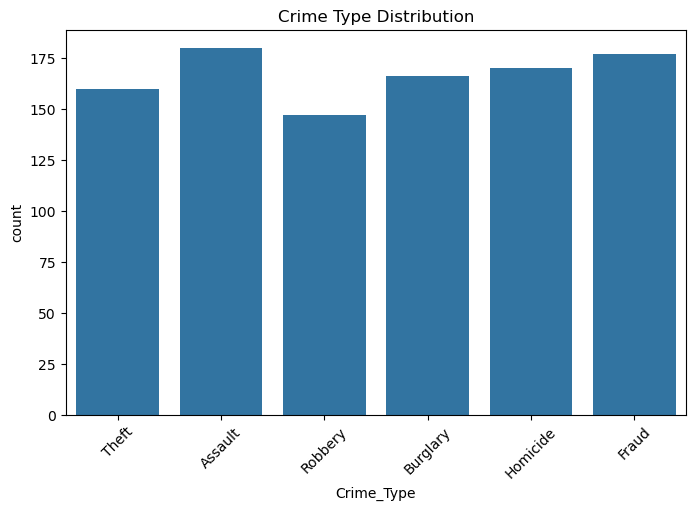

In [241]:
# Bar plot for crime types
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Crime_Type')
plt.xticks(rotation=45)
plt.title("Crime Type Distribution")
plt.show()

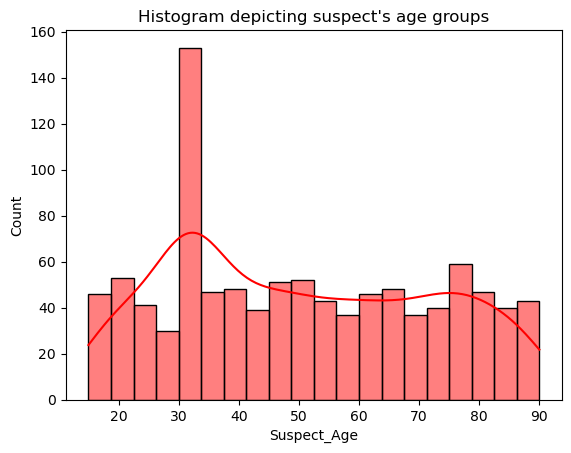

In [243]:
#Histogram depicting suspect's age groups
sns.histplot(df["Suspect_Age"],bins=20,kde=True,color="red")
plt.title("Histogram depicting suspect's age groups")
plt.show()

In [257]:
# Arrest rate for closed cases
closed_cases = df[df['Case_Status'] == 'Closed']
arrest_rate = closed_cases['Arrested'].mean() * 100  

print(f"Arrest Rate for Closed Cases: {arrest_rate:.2f}%")

Arrest Rate for Closed Cases: 57.53%


In [259]:
#Arrest Rates Across Case Status
status_arrest_rate = df.groupby('Case_Status')['Arrested'].mean() * 100
print(status_arrest_rate)

Case_Status
Closed                   57.530120
Open                     49.687500
Pending Investigation    52.011494
Name: Arrested, dtype: float64


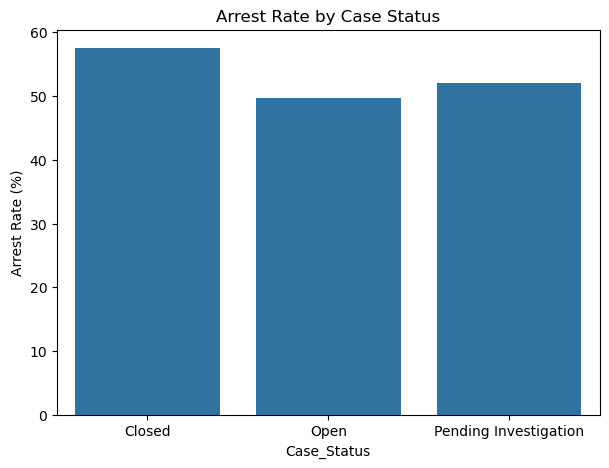

In [261]:
plt.figure(figsize=(7, 5))
sns.barplot(x=status_arrest_rate.index, y=status_arrest_rate.values)
plt.ylabel('Arrest Rate (%)')
plt.title('Arrest Rate by Case Status')
plt.show()

In [263]:
# Most Frequent Crime Types
crime_counts = df["Crime_Type"].value_counts()
crime_counts

Crime_Type
Assault     180
Fraud       177
Homicide    170
Burglary    166
Theft       160
Robbery     147
Name: count, dtype: int64

In [21]:
p = folium.Map(location=[27.771238, 87.800670], zoom_start=11)

# Add custom tile layer (Stamen Toner) with attribution
folium.TileLayer(
    'Stamen Toner',
    attr='Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL.'
).add_to(p)

# Add markers for each school based on latitude and longitude
for _, row in df.iterrows():
    popup_text = f"<b>{row['Crime_Type']}</b><br>City: {row['City']}<br>Severity: {row['Severity']}"
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=popup_text
    ).add_to(p)

# Display the map 
p

In [ ]:
#If Closed cases have high arrest rates, police work appears effective.
#If many Closed cases lack arrests, it could suggest cases are getting marked as resolved without actually solving them.
#Pending cases with high arrests may mean arrests happen before cases officially close.

In [11]:
#save processed data
df.to_csv('synthetic_crime_data_new.csv', index=False)
print("Processed data saved to 'synthetic_crime_data_new.csvs'")

Processed data saved to 'synthetic_crime_data_new.csvs'
